Install & Import Libraries

In [1]:
!pip install wfdb neurokit2 imbalanced-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 44.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [2]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
import scipy.signal as signal
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

Pan-Tompkins Implementation

In [3]:
def bandpass_filter(ecg, fs):
  lowcut = 5
  highcut = 15
  b, a = signal.butter(1, [lowcut/(fs/2), highcut/(fs/2)], btype='band')
  return signal.filtfilt(b, a, ecg)

def derivative_filter(ecg):
  return np.ediff1d(ecg)

def squaring(ecg):
  return ecg ** 2

def moving_window_integration(ecg, fs):
  window_size = int(0.15 * fs)
  return np.convolve(ecg, np.ones(window_size)/window_size, mode='same')

def detect_r_peaks(ecg, fs):
  distance = int(0.2 * fs)
  peaks, _ = signal.find_peaks(ecg, distance=distance, height=np.mean(ecg))
  return peaks

def pan_tompkins(ecg, fs):
  filtered = bandpass_filter(ecg, fs)
  derivative = derivative_filter(filtered)
  squared = squaring(derivative)
  integrated = moving_window_integration(squared, fs)
  r_peaks = detect_r_peaks(integrated, fs)
  return r_peaks, integrated

Load MIT-BIH ECG Data

In [4]:
train_records = ["100", "101", "102", "103"]
test_records = ["104", "105"]
data_path = "mitdb/"

wfdb.dl_database("mitdb", data_path)

# =========================
# 4. Function to build dataset
# =========================
def build_dataset(record_list):
    X, y = [], []

    for record_name in record_list:
        record = wfdb.rdsamp(data_path + record_name)
        ecg_signal = record[0][:, 0]
        fs = record[1]['fs']

        # ECG processing
        signals, info = nk.ecg_process(ecg_signal, sampling_rate=fs)
        cleaned = signals["ECG_Clean"]
        rpeaks = info["ECG_R_Peaks"]

        # Load annotations
        annotation = wfdb.rdann(data_path + record_name, 'atr')
        ann_samples = annotation.sample
        ann_symbols = annotation.symbol

        labels = np.array([0 if s == 'N' else 1 for s in ann_symbols])

        window_size = int(0.4 * fs)
        half_window = window_size // 2

        prev_r = None

        for r in rpeaks:
            start = r - half_window
            end = r + half_window

            if start > 0 and end < len(cleaned):
                beat = cleaned[start:end]

                # Align label
                idx = np.argmin(np.abs(ann_samples - r))

                if abs(ann_samples[idx] - r) < 50:
                    label = labels[idx]

                    # Normalize beat
                    beat = (beat - np.mean(beat)) / (np.std(beat) + 1e-8)

                    # === Feature engineering ===
                    # RR interval
                    rr = (r - prev_r) / fs if prev_r is not None else 0
                    prev_r = r

                    # amplitude
                    amplitude = np.max(beat) - np.min(beat)

                    # energy
                    energy = np.sum(beat**2)

                    # Combine features
                    beat_features = np.concatenate([beat, [rr, amplitude, energy]])

                    X.append(beat_features)
                    y.append(label)

    return np.array(X), np.array(y)


Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

Build Test Set

In [5]:
X_train, y_train = build_dataset(train_records)
X_test, y_test = build_dataset(test_records)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8373, 147)
Test shape: (4721, 147)


Handle Imbalance

In [6]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train))

After SMOTE: [6275 6275]


Convert to Array

In [7]:
X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (12550, 147)
Test: (4721, 147)


Plot Raw ECG Signal

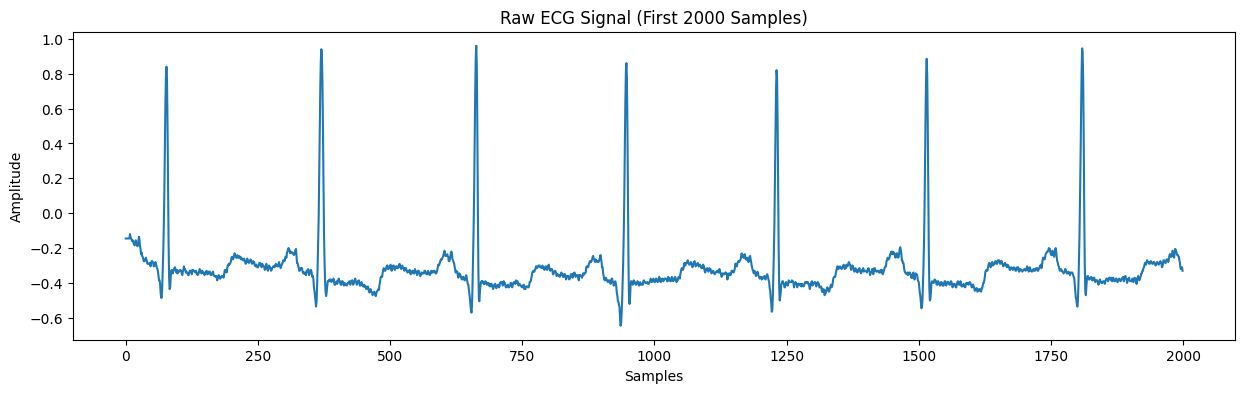

In [8]:
record = wfdb.rdsamp(data_path + "100")

ecg_signal = record[0][:, 0]
fs = record[1]['fs']

plt.figure(figsize=(15,4))
plt.plot(ecg_signal[:2000])
plt.title("Raw ECG Signal (First 2000 Samples)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

Clean / Filter ECG Signal

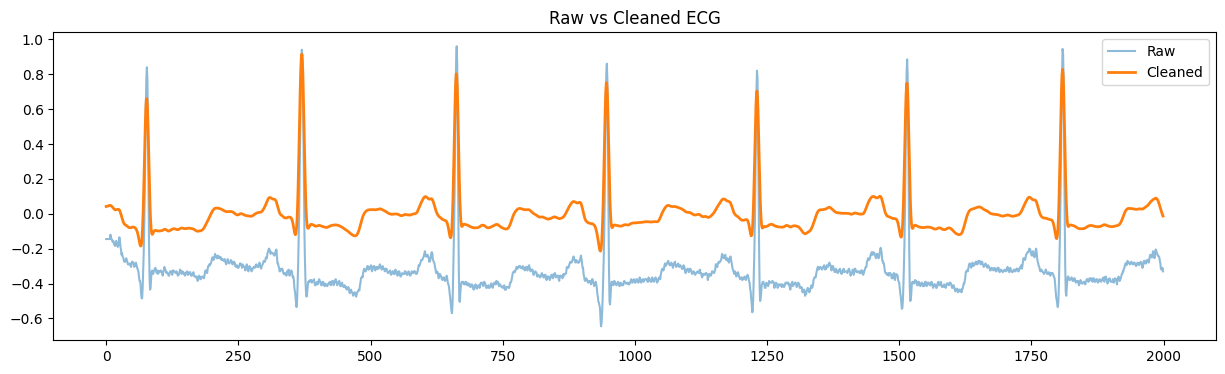

In [9]:
cleaned = nk.ecg_clean(ecg_signal, sampling_rate=fs, method="neurokit")

plt.figure(figsize=(15,4))
plt.plot(ecg_signal[:2000], label="Raw", alpha=0.5)
plt.plot(cleaned[:2000], label="Cleaned", linewidth=2)
plt.legend()
plt.title("Raw vs Cleaned ECG")
plt.show()

Detect R-Peaks (QRS Complex)

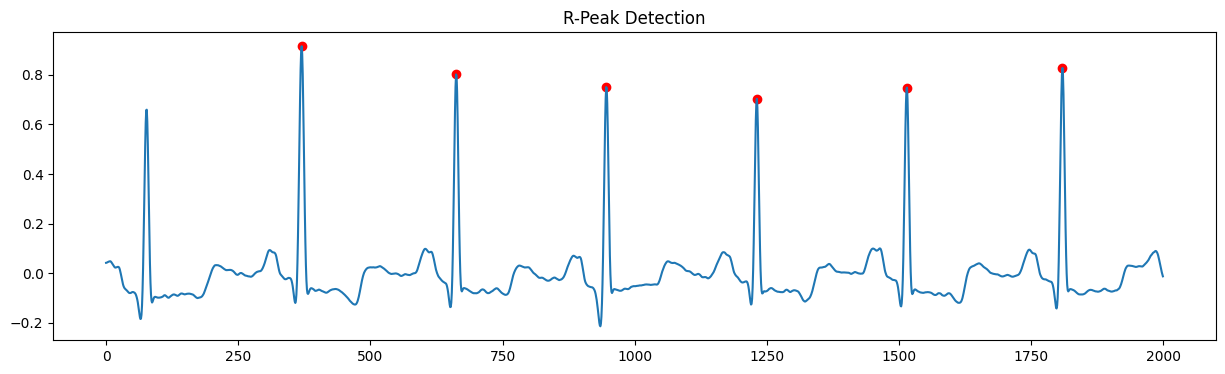

Number of R-Peaks Detected: 2271


In [10]:
signals, info = nk.ecg_process(ecg_signal, sampling_rate=fs)
rpeaks = info["ECG_R_Peaks"]

plt.figure(figsize=(15,4))
plt.plot(cleaned[:2000])
plt.scatter(rpeaks[rpeaks < 2000], cleaned[rpeaks[rpeaks < 2000]], color='red')
plt.title("R-Peak Detection")
plt.show()

print("Number of R-Peaks Detected:", len(rpeaks))

Segment Heartbeats

In [11]:
window_size = int(0.6 * fs)
half_window = window_size

beats = []

for r in rpeaks:
  start = r - half_window
  end = r + half_window

  if start > 0 and end < len(cleaned):
    beat = cleaned[start:end]
    beats.append(beat)

beats = np.array(beats)
print("Shape of beats:", beats.shape)

Shape of beats: (2271, 432)


Plot Individual Heartbeats

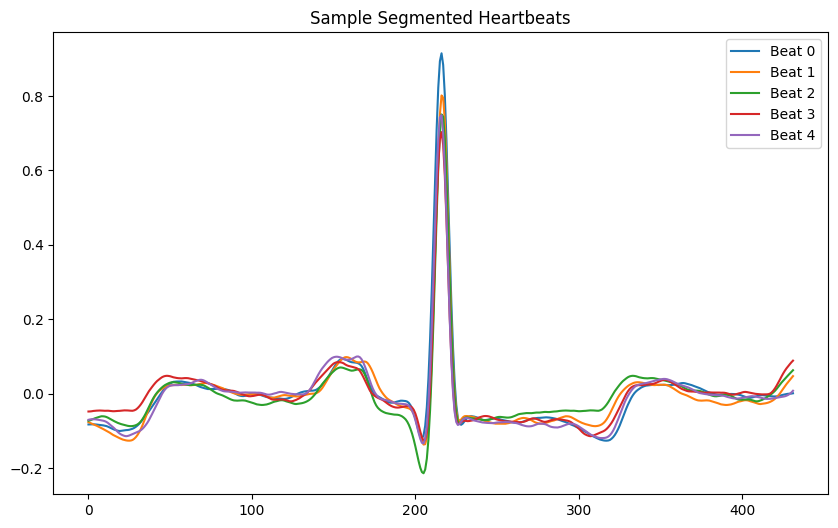

In [12]:
plt.figure(figsize=(10,6))

for i in range(5):
  plt.plot(beats[i], label=f"Beat {i}")

plt.title("Sample Segmented Heartbeats")
plt.legend()
plt.show()

Visualize Average Heartbeat

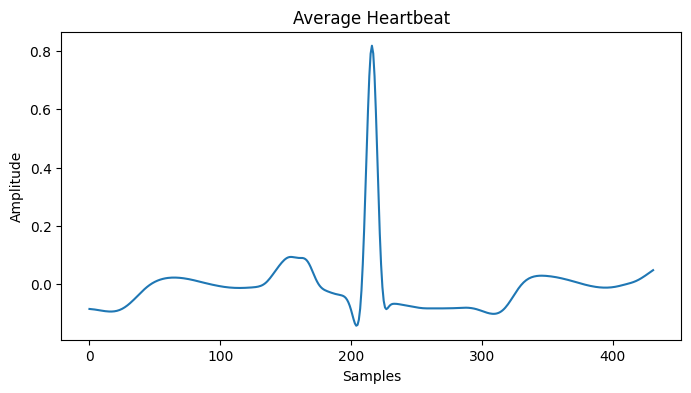

In [13]:
avg_beat = np.mean(beats, axis=0)

plt.figure(figsize=(8,4))
plt.plot(avg_beat)
plt.title("Average Heartbeat")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

Load Annotations (Ground Truth)

In [14]:
annotation = wfdb.rdann(data_path + "100", 'atr')

ann_samples = annotation.sample
ann_symbols = annotation.symbol

print(ann_samples[:10])
print(ann_symbols[:10])

[  18   77  370  662  946 1231 1515 1809 2044 2402]
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


Map Labels -> Normal vs Arrythmia

In [15]:
def label_map(symbol):
  if symbol == 'N':
    return 0
  else:
    return 1

labels = np.array([label_map(s) for s in ann_symbols])

Align Labels with R-Peaks

In [16]:
beat_labels = []

for r in rpeaks:
  idx = np.argmin(np.abs(ann_samples - r))
  beat_labels.append(labels[idx])

beat_labels = np.array(beat_labels)

print("Beats:", beats.shape)
print("Labels:", beat_labels.shape)

Beats: (2271, 432)
Labels: (2271,)


Clean Dataset (Remove Mismatch)

In [17]:
min_len = min(len(beats), len(beat_labels))
X = beats[:min_len]
y = beat_labels[:min_len]

print("Final Dataset:", X.shape, y.shape)

Final Dataset: (2271, 432) (2271,)


Train / Test Split

In [18]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_flat, y_train)

Train Classifier (Random Forest)

In [19]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_res, y_train_res,
    test_size=0.2,
    stratify=y_train_res,
    random_state=42
)

Train Random Forest on Training Split

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_tr, y_tr)

RandomForestClassifier(random_state=42)

Threshold Tuning

In [21]:
y_val_prob = rf_model.predict_proba(X_val)[:, 1]

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val, y_val_prob)

target_recall = 0.80
idx = np.where(recall >= target_recall)[0][0]
precision = precision[:-1]
recall = recall[:-1]

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1)
best_thr_rf = thresholds[best_idx]

print("RF Best Threshold (validation):", best_thr_rf)

RF Best Threshold (validation): 0.77


Proper evaluation

In [22]:
y_prob_rf = rf_model.predict_proba(X_test_flat)[:, 1]
y_pred_rf = (y_prob_rf > 0.3).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("\nRandom Forest Results (Test Set)")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


Random Forest Results (Test Set)
[[2406  246]
 [  40 2029]]
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      2652
           1       0.89      0.98      0.93      2069

    accuracy                           0.94      4721
   macro avg       0.94      0.94      0.94      4721
weighted avg       0.94      0.94      0.94      4721

ROC-AUC: 0.9447255944427069


Quick Checks

In [23]:
print("Train size:", X_train.shape, np.bincount(y_train))
print("Test size:", X_test.shape, np.bincount(y_test))

Train size: (12550, 147) [6275 6275]
Test size: (4721, 147) [2652 2069]


Confusion Matrix

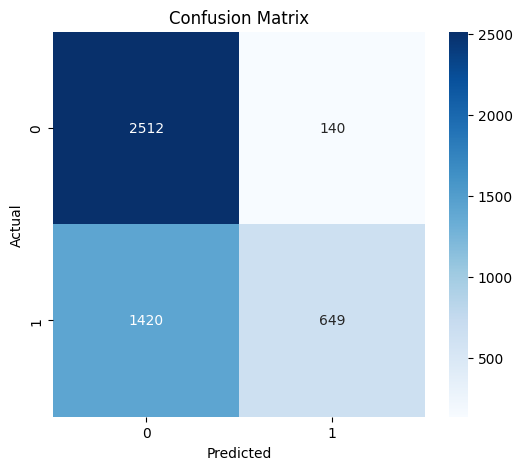

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict
y_pred = rf_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Class Distribution

In [25]:
unique, counts = np.unique(y, return_counts=True)

print("Class Distribution:")
for u, c in zip(unique,counts):
  print("Normal" if u == 0 else "Arrythmia", ":", c)

Class Distribution:
Normal : 2237
Arrythmia : 34


Prepare Data for Small Neural Network (SNN)

In [26]:
X_nn = X.reshape(X.shape[0], -1)

print("NN imput shape:", X_nn.shape)

NN imput shape: (2271, 432)


Normalize Features

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_nn = scaler.fit_transform(X_nn)

Train / Test Split

In [28]:
from sklearn.model_selection import train_test_split

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn, y, test_size=0.2, random_state=42, stratify=y
)

Build Small Neural Network (SNN)

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.5),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [30]:
model_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        55,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,793 (257.00 KB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [31]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_nn)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_nn)

class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

history_nn = model_nn.fit(
    X_train_nn,
    y_train_nn,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

Class weights: {np.int64(0): np.float64(0.5075461151481274), np.int64(1): np.float64(33.629629629629626)}
Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8850 - loss: 2.0665 - val_accuracy: 0.9808 - val_loss: 0.1528
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9298 - loss: 1.3206 - val_accuracy: 0.9643 - val_loss: 0.1297
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9187 - loss: 0.2792 - val_accuracy: 0.9780 - val_loss: 0.0776
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9435 - loss: 0.2659 - val_accuracy: 0.9753 - val_loss: 0.0711
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9146 - loss: 0.5390 - val_accuracy: 0.9863 - val_loss: 0.0619
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9552 - loss: 0.0718 - val_accuracy: 0.9890 - val_loss: 0.0544
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9518 - loss: 0.2080 - val_accuracy: 0.9890 - val_loss: 0.0561
Epoch 8/20

Evaluate Model

In [32]:
loss,acc = model_nn.evaluate(X_test_nn, y_test_nn)
print("NN Test Accuracy:", acc)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0015     
NN Test Accuracy: 1.0


Detailed Metrics

In [33]:
y_pred_prob = model_nn.predict(X_test_nn)
y_pred = (y_pred_prob > 0.6).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test_nn, y_pred))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       448
           1       1.00      1.00      1.00         7

    accuracy                           1.00       455
   macro avg       1.00      1.00      1.00       455
weighted avg       1.00      1.00      1.00       455



NOTE: Logistic Regression instead of Linear Regression as it is perfect for binary classification

Prepare Data

In [34]:
X_lr = X.reshape(X.shape[0], -1)

Normalize Features

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_lr = scaler.fit_transform(X_lr)

Train / Test Split

In [36]:
from sklearn.model_selection import train_test_split

X_trian_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y, test_size=0.2, random_state=42, stratify=y
)

Train Logistic Regression

In [37]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000, class_weight='balanced')
model_lr.fit(X_trian_lr, y_train_lr)

LogisticRegression(class_weight='balanced', max_iter=1000)

Evaluate Model

In [38]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_lr = model_lr.predict(X_test_lr)

print("Logistic Regression Accuracy:", accuracy_score(y_test_lr, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test_lr, y_pred_lr))

Logistic Regression Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       448
           1       1.00      1.00      1.00         7

    accuracy                           1.00       455
   macro avg       1.00      1.00      1.00       455
weighted avg       1.00      1.00      1.00       455



Tune Class Weights

In [39]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight={0:1, 1:2})

Find Best Threshold

In [42]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Probability for positive class
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# F1 score
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (
    precision[:-1] + recall[:-1] + 1e-8
)

# Best threshold
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Best Precision:", precision[best_idx])
print("Best Recall:", recall[best_idx])
print("Best F1:", f1_scores[best_idx])

Best Threshold: 0.35
Best Precision: 0.8983504235399019
Best Recall: 0.9739004349927501
Best F1: 0.9346011081806835


Add Post-Processing Filter

In [43]:
y_pred_smoothed = y_pred.copy()

for i in range(1, len(y_pred)-1):
    if y_pred[i] == 1 and y_pred[i-1] == 0 and y_pred[i+1] == 0:
        y_pred_smoothed[i] = 0

Verify with Actual Predictions

In [44]:
y_pred = (y_prob > best_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.92      0.94      2652
           1       0.90      0.97      0.93      2069

    accuracy                           0.94      4721
   macro avg       0.94      0.94      0.94      4721
weighted avg       0.94      0.94      0.94      4721



Install & Imports for Convolutional Neural Networks

In [45]:
!pip install tensorflow

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

Reshape Data for CNN

In [46]:
X_train_cnn = X_train[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

print(X_train_cnn.shape, X_test_cnn.shape)

(12550, 147, 1) (4721, 147, 1)


Build CNN Model

In [47]:
model = Sequential([
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 143, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 143, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 71, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 67, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 67, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 33, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 31, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 31, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       245,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 290,305 (1.11 MB)

 Trainable params: 289,857 (1.11 MB)

 Non-trainable params: 448 (1.75 KB)

Handle Imbalance

In [48]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.0), 1: np.float64(1.0)}


Train CNN

In [49]:
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

history = model.fit(
    X_train_cnn, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 138ms/step - accuracy: 0.9938 - auc: 0.9992 - loss: 0.0192 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.1037
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - accuracy: 0.9989 - auc: 0.9999 - loss: 0.0038 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 1.4062e-04
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - accuracy: 0.9992 - auc: 0.9999 - loss: 0.0030 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 5.9100e-06
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.9999 - auc: 1.0000 - loss: 3.6889e-04 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 5.4632e-06
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9999 - auc: 1.0000 - loss: 1.5156e-04 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 4.5118e-05
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 7.4600e-05 - val_accuracy: 1.0000 - val_auc: 0.0000

Evaluate CNN

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_prob = model.predict(X_test_cnn).ravel()
y_pred = (y_prob > 0.5).astype(int)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Confusion Matrix:
 [[2472  180]
 [ 342 1727]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90      2652
           1       0.91      0.83      0.87      2069

    accuracy                           0.89      4721
   macro avg       0.89      0.88      0.89      4721
weighted avg       0.89      0.89      0.89      4721

ROC-AUC: 0.9674065261305473


Threshold Tuning

In [51]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print("\nBest Threshold:", best_threshold)



Best Threshold: 0.2542919
